In [ ]:
# %%
from __future__ import print_function

import numpy as np 
import matplotlib.pyplot as plt
import openpathsampling as paths

import aimmd
import aimmdTIS 


fatal: not a git repository (or any of the parent directories): .git
/Users/rbreeba/miniconda3/envs/py39_AIMMD-TIS/lib/python3.9/site-packages/aimmd/base/storage.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
import openpathsampling.engines.toy as toys
settings = {"n_harmonics": 0,
            "rotation_degrees": 0,
            "scale": 2}
pes = aimmdTIS.potential_switch("wolfe-quapp", settings)
n_harmonics = pes.n_harmonics


123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0., 0.])


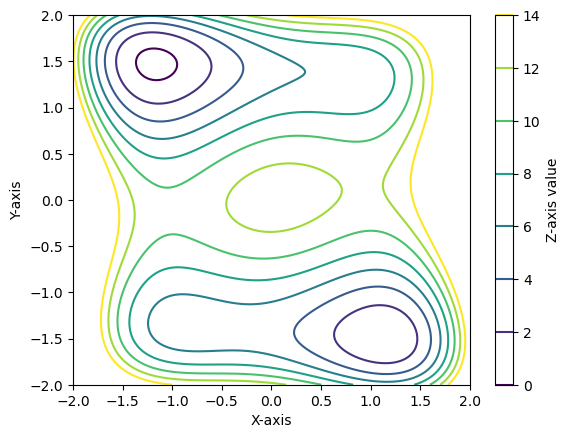

In [7]:
x = np.linspace(pes.extent[0],pes.extent[1],300)
y = np.linspace(pes.extent[2],pes.extent[3],300)
x_2d, y_2d, U = pes.plot_2d_pes(x,y)
# Step 2: Create the colormap
colormap = 'plasma'  # You can choose a different colormap from Matplotlib's colormaps

# Step 3: Generate the 2D image

plt.figure()
plt.contour(x_2d,y_2d,U, levels = pes.levels)
plt.colorbar(label='Z-axis value')  # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [8]:

integ = toys.LangevinBAOABIntegrator(dt=0.02, temperature=0.1, gamma=2.5)
options={
    'integ' : integ,
    'n_frames_max' : 5000,
    'n_steps_per_frame' : 1
}
toy_eng = toys.Engine(
    options=options,
    topology=pes.topology
)
toy_eng.initialized = True

template = pes.template(toy_eng)
toy_eng.current_snapshot = template
paths.PathMover.engine = toy_eng

# Collective variables to define the states
opA = paths.CoordinateFunctionCV(name="opA", f=pes.stable_interface_function, center=pes.state_A)
opB = paths.CoordinateFunctionCV(name="opB", f=pes.stable_interface_function, center=pes.state_B)

# State volumes in CV space
stateA = paths.CVDefinedVolume(opA, 0.0, pes.state_boundary).named('StateA')
stateB = paths.CVDefinedVolume(opB, 0.0, pes.state_boundary).named('StateB')
#

In [9]:
# Fake an initial trajectory
init_AB = paths.Trajectory(pes.simple_initial_path(100,toy_eng))


In [10]:
def xval(snapshot):
    return snapshot.xyz[0][0]

cvX = paths.CoordinateFunctionCV(name="cvX", f=xval).with_diskcache()

In [11]:
interface_value = -0.5

In [12]:
print("Creating interfaces...")
interface = paths.VolumeInterfaceSet(cvX, minvals=-float("inf"), maxvals=interface_value) #for interface of paths going from A to B

Creating interfaces...


In [13]:
# %%
TIS = True
if TIS:
    network = paths.MISTISNetwork([(stateA, interface, stateB)]).named('mstis')
else:
    network = paths.TPSNetwork(stateA, stateB).named('tps')
move_scheme = paths.OneWayShootingMoveScheme(network, 
                                            engine=toy_eng).named("scheme")
# %%
initial_conditions = move_scheme.initial_conditions_from_trajectories(init_AB)

# %%
initial_conditions.sanity_check()


No missing ensembles.
No extra ensembles.


In [14]:
# %%
storage = paths.Storage("simple_store.nc", "w", template=template)
storage.save(initial_conditions)
storage.save(toy_eng)
storage.save(network)
storage.save(move_scheme)


(store.schemes[MoveScheme] : 1 object(s),
 14,
 104173590045148678838235097194383278852)

In [15]:
sampler = paths.PathSampling(storage, move_scheme, initial_conditions)

n_run = 50
sampler.run(n_run)

Working on Monte Carlo cycle number 50
Running for 3 seconds -  0.07 seconds per step
Estimated time remaining: 0 seconds
DONE! Completed 50 Monte Carlo cycles.


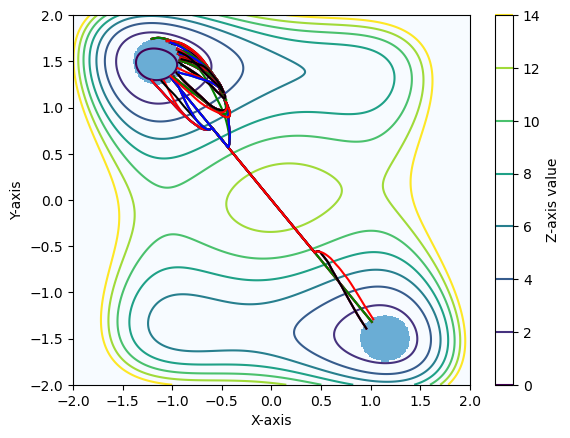

In [16]:
trajectories = [step.active[0].trajectory for step in storage.steps[:]]
plt.figure()
plt.contour(x_2d,y_2d,U, pes.levels)
plt.colorbar(label='Z-axis value') 
repcolordict = {0 : 'k-', 1 : 'r-', 2 : 'g-', 3 : 'b-', 4 : 'r-'}
for i, traj in enumerate(trajectories):
    plt.plot(traj.xyz[:,0,0], traj.xyz[:,0,1], repcolordict[i % 5])

states_plot = np.vectorize(aimmdTIS.CallableVolume(stateA))(x_2d, -y_2d)
states_plot += np.vectorize(aimmdTIS.CallableVolume(stateB))(x_2d, -y_2d)
plt.imshow(states_plot, extent=pes.extent, cmap="Blues",
            interpolation='nearest', vmin=0.0, vmax=2.0,
            aspect='auto')
 # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [17]:
storage.close()